# 🍿 Netflix Data Analysis & Visualization

In this project, we analyze a comprehensive dataset of Netflix movies and TV shows. The dataset includes details such as titles, genres, directors, release dates, durations, ratings, and countries of origin.

**Key Objectives:**
1. **Data Cleaning & Processing:** Handle missing values, remove duplicates, and parse date objects for temporal analysis.
2. **Exploratory Data Analysis (EDA):** Discover trends over time, identify top content-producing countries, and explore the most popular genres and directors.
3. **Visualization:** Utilize `matplotlib`, `seaborn`, and `wordcloud` to create rich, informative visual representations of the Netflix catalog.

*(Note: As this dataset is largely descriptive and categorical, the scope of this project focuses heavily on Exploratory Data Analysis rather than Machine Learning.)*

In [3]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import warnings

# Set visualization style
sns.set_theme(style="whitegrid")
warnings.filterwarnings('ignore')

## 1. Data Loading & Inspection
Let's load the dataset and perform an initial inspection to understand its structure, size, and missing values.

In [4]:
# Loading and inspecting the data
df = pd.read_csv('Netflix_data_cleaning_analysis_and_visualisation.csv')

# Display basic info and first few rows
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8790 entries, 0 to 8789
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   country       8790 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   listed_in     8790 non-null   object
dtypes: int64(1), object(9)
memory usage: 686.8+ KB


,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,9/25/2021,2020,PG-13,90 min,Documentaries
1,s3,TV Show,Ganglands,Julien Leclercq,France,9/24/2021,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act..."
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,9/24/2021,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries"
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,9/22/2021,2021,TV-PG,91 min,"Children & Family Movies, Comedies"
4,s8,Movie,Sankofa,Haile Gerima,United States,9/24/2021,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies"


## 2. Data Cleaning & Feature Engineering
We need to clean the data by dropping duplicates and handling missing values in columns like `director`, `country`, and `date_added`. We will also engineer new temporal features (Year, Month) from the date columns.

In [5]:
# Cleaning and Processing the data for EDA
# Drop duplicates
df.drop_duplicates(inplace=True)

# Handle missing/unknown values ('Not Given' and NaNs)
df['director'] = df['director'].replace('Not Given', 'Not Specified').fillna('Not Specified')
df['country'] = df['country'].replace('Not Given', 'Not Specified').fillna('Not Specified')
df['date_added'] = df['date_added'].ffill()

# Convert string dates to datetime objects
df['date_added'] = pd.to_datetime(df['date_added'])

# Extract useful temporal features
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

# Extract numerical duration for movies
df['duration_num'] = df['duration'].str.extract(r'(\d+)').astype(float)

df.head()

,show_id,type,title,director,country,date_added,release_year,rating,duration,listed_in,year_added,month_added,duration_num
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,United States,2021-09-25,2020,PG-13,90 min,Documentaries,2021,September,90.0
1,s3,TV Show,Ganglands,Julien Leclercq,France,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",2021,September,1.0
2,s6,TV Show,Midnight Mass,Mike Flanagan,United States,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",2021,September,1.0
3,s14,Movie,Confessions of an Invisible Girl,Bruno Garotti,Brazil,2021-09-22,2021,TV-PG,91 min,"Children & Family Movies, Comedies",2021,September,91.0
4,s8,Movie,Sankofa,Haile Gerima,United States,2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies",2021,September,125.0


## 3. Exploratory Data Analysis (EDA)
In this section, we will explore the distribution of content types, the top producing countries, and overall trends over time.

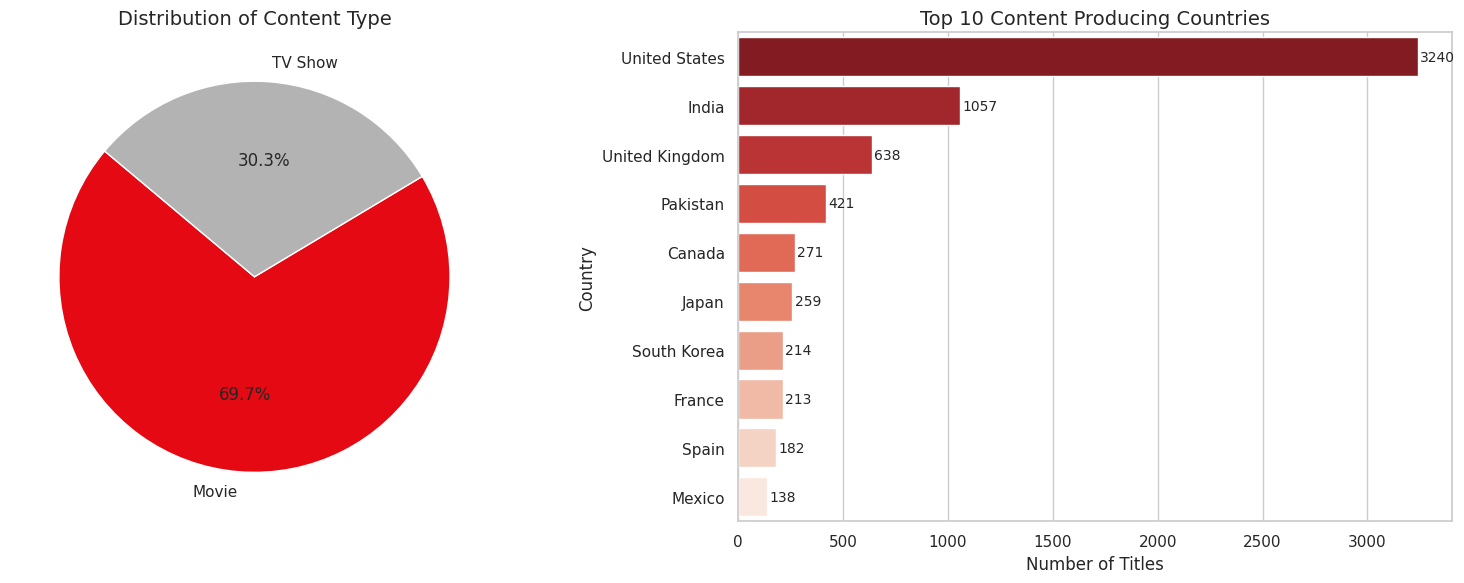

In [6]:
# Content Distribution & Top Countries
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribution of content type (Netflix brand colors)
content_counts = df['type'].value_counts()
axes[0].pie(content_counts, labels=content_counts.index, autopct='%1.1f%%', startangle=140, colors=['#E50914', '#B3B3B3'])
axes[0].set_title('Distribution of Content Type', fontsize=14)

# Top countries producing Netflix content (Excluding 'Not Specified')
top_countries = df['country'].value_counts()
if 'Not Specified' in top_countries:
    top_countries = top_countries.drop('Not Specified')
top_countries = top_countries.head(10)

sns.barplot(x=top_countries.values, y=top_countries.index, palette='Reds_r', ax=axes[1])
for i, val in enumerate(top_countries.values):
    axes[1].text(val + 10, i, str(val), va='center', fontsize=10)

axes[1].set_title('Top 10 Content Producing Countries', fontsize=14)
axes[1].set_xlabel('Number of Titles')
axes[1].set_ylabel('Country')

plt.tight_layout()
plt.show()

As seen above, Movies dominate the platform, making up roughly 70% of the content. The United States and India are by far the largest producers of Netflix content.

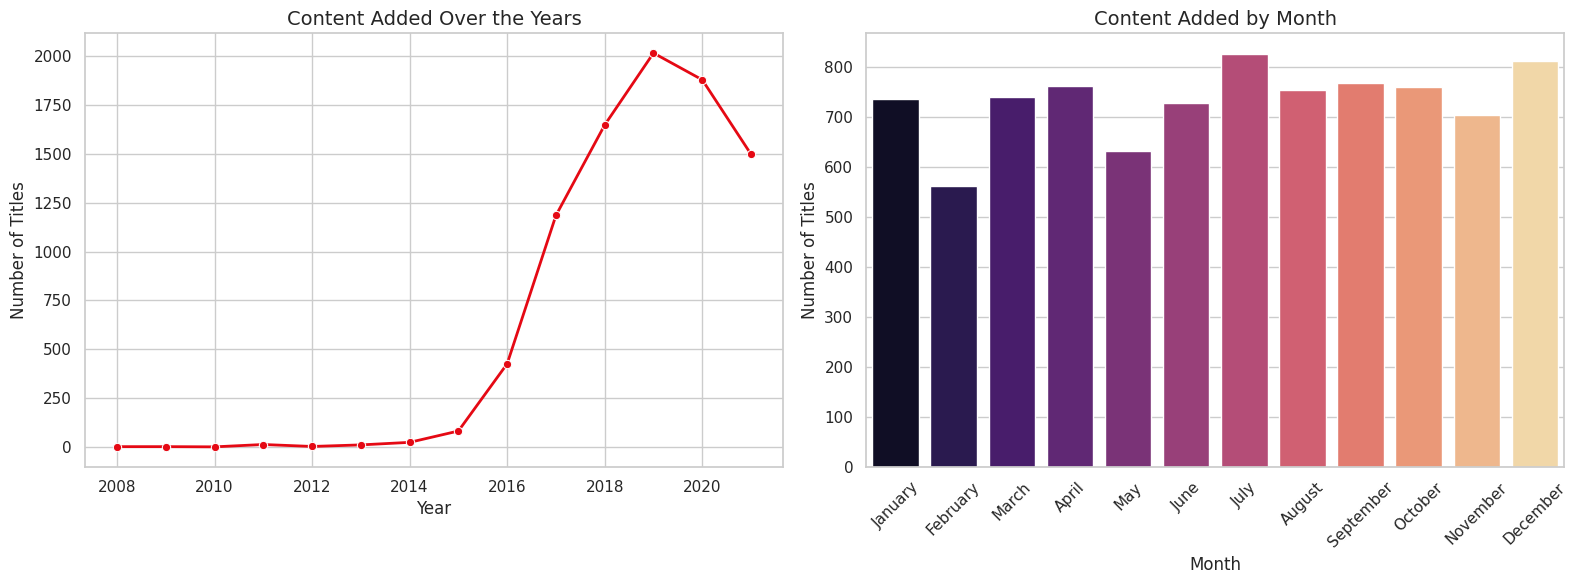

In [7]:
# Content added over time (Yearly and Monthly)
year_counts = df['year_added'].value_counts().sort_index()
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_counts = df['month_added'].value_counts().reindex(month_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Yearly Line Plot
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o', color='#E50914', linewidth=2, ax=axes[0])
axes[0].set_title('Content Added Over the Years', fontsize=14)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Number of Titles')

# Monthly Bar Plot
sns.barplot(x=month_counts.index, y=month_counts.values, palette='magma', ax=axes[1])
axes[1].set_title('Content Added by Month', fontsize=14)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Number of Titles')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Netflix experienced a massive surge in content acquisition starting around 2015, peaking recently. Interestingly, content drops are fairly evenly distributed across months, with slight bumps in July and December.

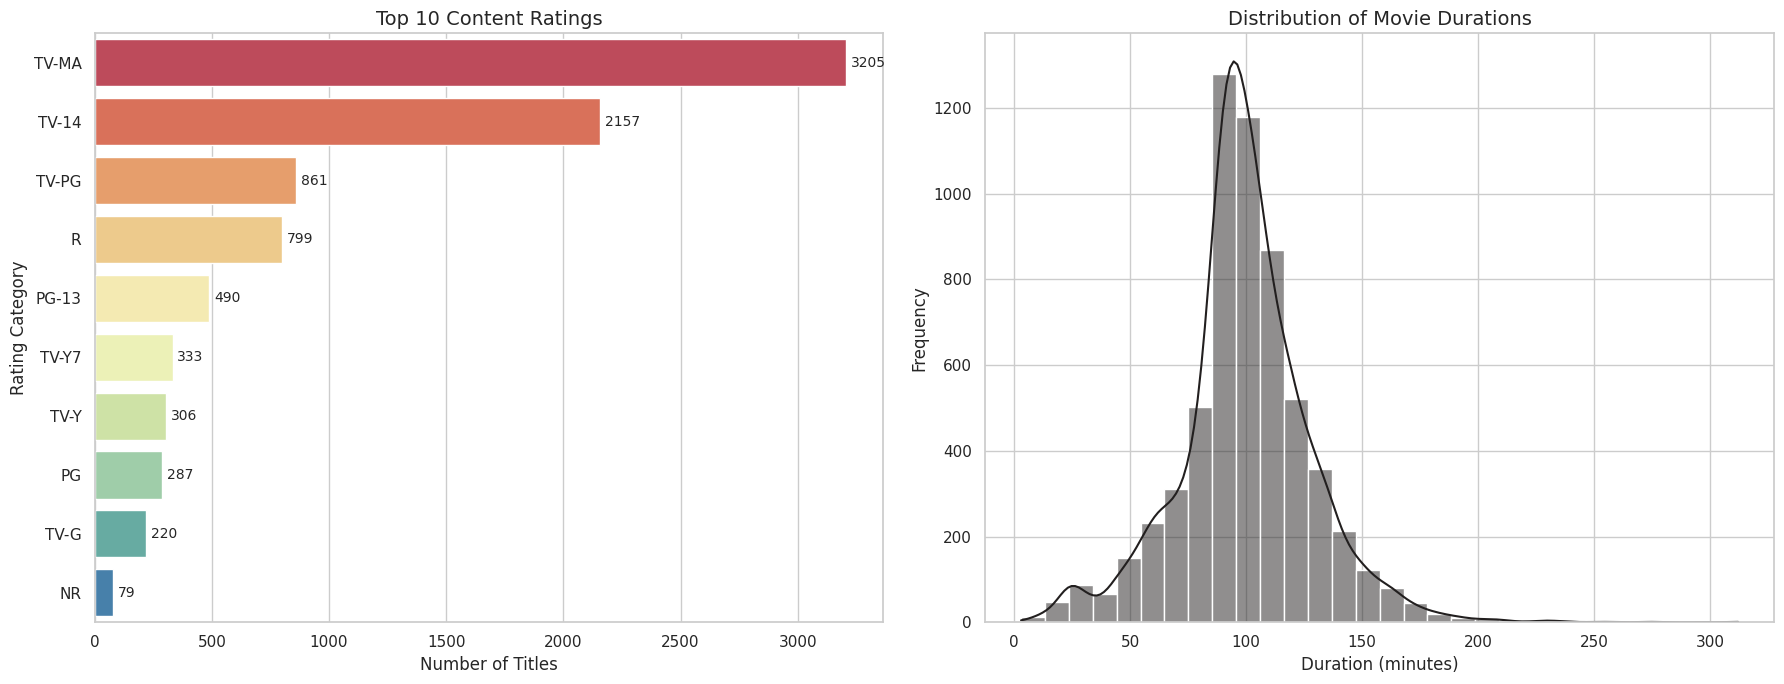

In [8]:
# Ratings Distribution & Movie Durations
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Bar chart for Ratings
rating_counts = df['rating'].value_counts().head(10)
sns.barplot(x=rating_counts.values, y=rating_counts.index, palette='Spectral', ax=axes[0])
for i, val in enumerate(rating_counts.values):
    axes[0].text(val + 20, i, str(val), va='center', fontsize=10)
axes[0].set_title('Top 10 Content Ratings', fontsize=14)
axes[0].set_xlabel('Number of Titles')
axes[0].set_ylabel('Rating Category')

# Histogram for Movie Durations
sns.histplot(df[df['type'] == 'Movie']['duration_num'], bins=30, kde=True, color='#221F1F', ax=axes[1])
axes[1].set_title('Distribution of Movie Durations', fontsize=14)
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

Mature content (TV-MA) dominates the platform by a wide margin. As for movie durations, a normal distribution is evident, with the vast majority of films falling into the traditional 90 to 110-minute window.

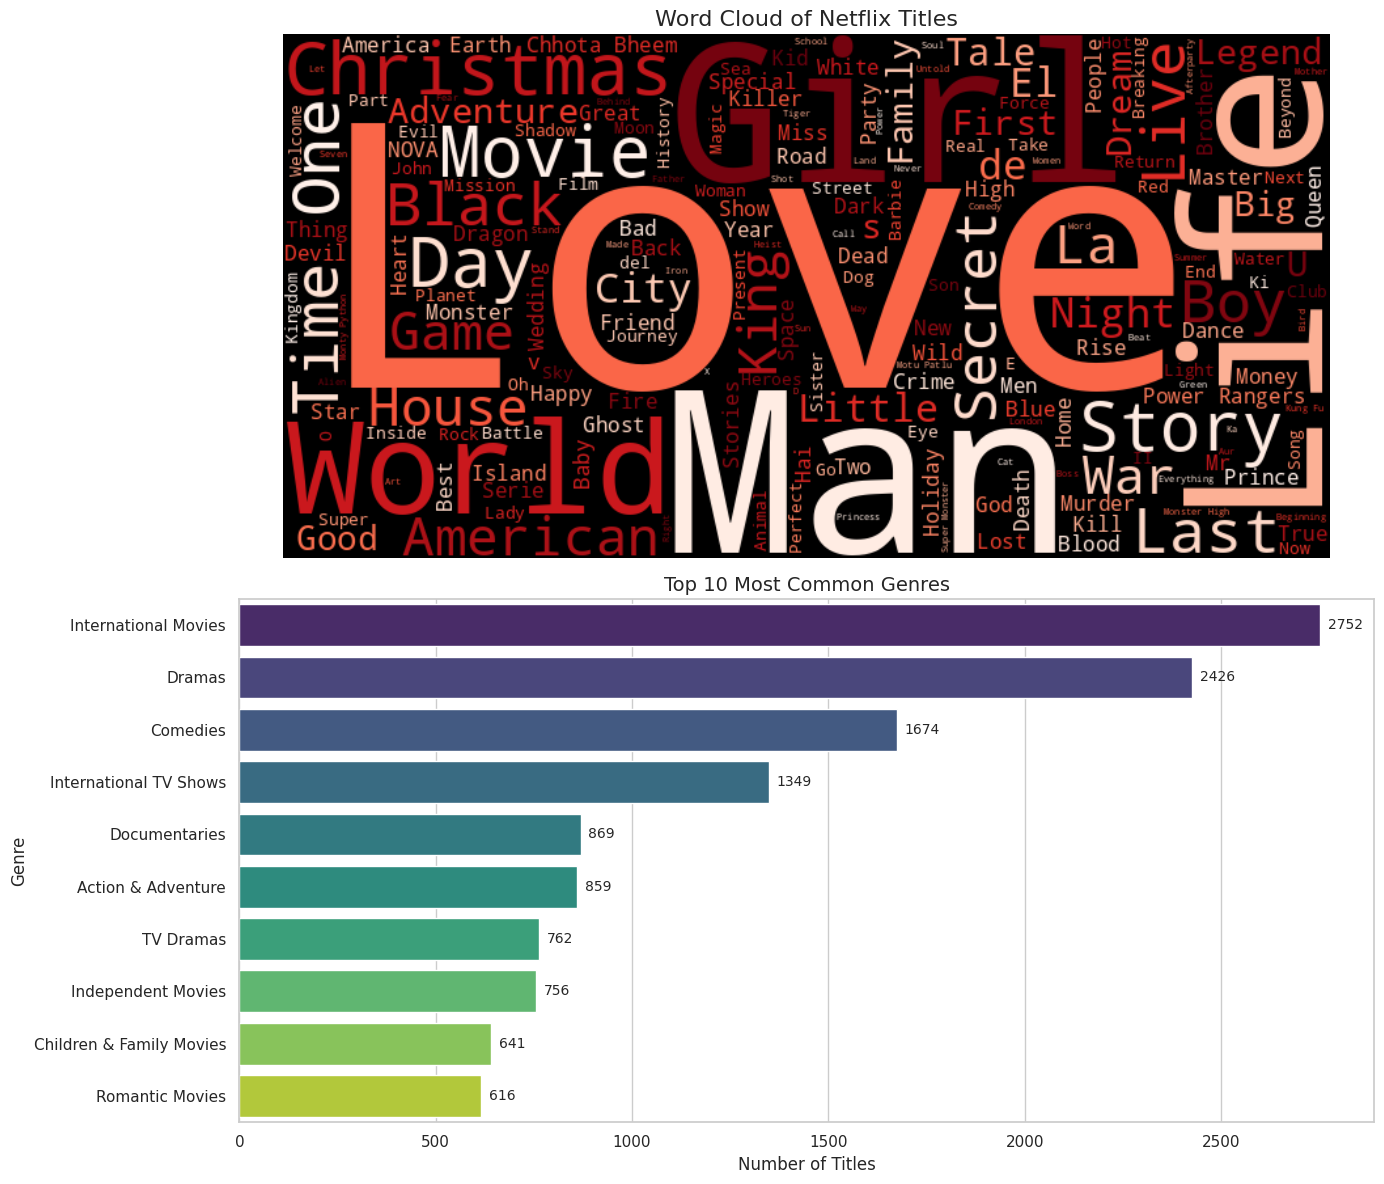

In [9]:
# Text Analysis & Top Genres
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

# Word Cloud of Titles
text = ' '.join(df['title'].dropna().astype(str))
wordcloud = WordCloud(width=800, height=400, background_color='black',
                      colormap='Reds', stopwords=STOPWORDS).generate(text)

axes[0].imshow(wordcloud, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Word Cloud of Netflix Titles', fontsize=16)

# Top 10 Genres
all_genres = df['listed_in'].str.split(',').explode().str.strip()
genre_counts = all_genres.value_counts().head(10)

sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='viridis', ax=axes[1])
for index, value in enumerate(genre_counts.values):
    axes[1].text(value + 20, index, str(value), va='center', fontsize=10)

axes[1].set_title('Top 10 Most Common Genres', fontsize=14)
axes[1].set_xlabel('Number of Titles')
axes[1].set_ylabel('Genre')

plt.tight_layout()
plt.show()

### Conclusion
The Exploratory Data Analysis reveals several key insights:
* **Content Dominance:** Movies represent the majority (70%) of Netflix's catalog compared to TV Shows (30%).
* **Global Reach:** While the United States is the largest contributor, international markets (specifically India) play a massive role in Netflix's portfolio.
* **Audience:** The platform skews heavily toward mature audiences (TV-MA).
* **Content Type:** International Movies, Dramas, and Comedies are the most heavily saturated genres, indicating a strong preference for culturally diverse, fictional storytelling.